In [1]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
from shapely.geometry import LineString

FP_MANZ = Path("../data/processed/censo/manzanas_penalolen_sim.parquet")
FP_WALK = Path("../data/processed/eod/tabla_walk_prob.csv")
FP_PURP = Path("../data/processed/eod/tabla_purpose_prob.csv")
FP_TIME = Path("../data/processed/eod/tabla_tiempos_caminata.csv")


FP_RED = Path("../data/raw/red_peatonal_penalolen.graphml")
FP_SALUD = Path("../data/raw/establecimientos_salud_penalolen.gpkg")

print("Cargando red peatonal...")
G = ox.load_graphml(FP_RED)

print("Cargando establecimientos de salud...")
centros = gpd.read_file(FP_SALUD)

# asegurar CRS común
G = ox.project_graph(G, to_crs="EPSG:32719")
centros = centros.to_crs("EPSG:32719")

print("CRS centros:", centros.crs)

Cargando red peatonal...
Cargando establecimientos de salud...
CRS centros: EPSG:32719


In [2]:
manz = gpd.read_parquet(FP_MANZ)
tabla_walk = pd.read_csv(FP_WALK)
tabla_purp = pd.read_csv(FP_PURP)
tabla_time = pd.read_csv(FP_TIME)

print(manz.shape)
print(tabla_walk.head())
print(tabla_purp.head())
print(tabla_time.head())

(1629, 14)
  vuln_group  n_expand_total  n_expand_walk  p_walk_pure
0       baja     5435.166627    1819.096319     0.334690
1      media     5043.790750    2061.902945     0.408800
2       alta     5350.015259    2599.728057     0.485929
  vuln_group      purpose_group    n_expand      prob
0       baja   compras_tramites  633.793235  0.768157
1       baja              salud   29.224046  0.035420
2       baja  social_recreacion  162.066159  0.196424
3      media   compras_tramites  729.453542  0.782280
4      media              salud   43.577654  0.046734
  vuln_group      purpose_group    n  mean_time  median_time   p25   p75
0       baja   compras_tramites  429  11.624709         10.0   5.0  15.0
1       baja              salud   22  18.045455         15.0  10.0  25.0
2       baja  social_recreacion  113  14.761062         10.0   5.0  20.0
3      media   compras_tramites  494  12.773279         10.0   5.0  15.0
4      media              salud   31  20.193548         15.0  12.5  27.5

In [3]:
manz["n_agents"] = np.where(
    manz["n_edad_60_mas"] > 0,
    np.maximum(1, np.round(manz["n_edad_60_mas"] / 10).astype(int)),
    0
)

print(manz[["n_edad_60_mas", "n_agents"]].describe())
print("Total agentes a simular:", manz["n_agents"].sum())

       n_edad_60_mas     n_agents
count    1629.000000  1629.000000
mean       27.457336     2.796194
std        29.195460     2.879686
min         0.000000     0.000000
25%        13.000000     1.000000
50%        21.000000     2.000000
75%        31.000000     3.000000
max       345.000000    34.000000
Total agentes a simular: 4555


In [4]:
rows = []

for _, row in manz.iterrows():
    n = int(row["n_agents"])
    if n <= 0:
        continue

    for i in range(n):
        rows.append({
            "MANZENT": row["MANZENT"],
            "COD_MANZANA": row["COD_MANZANA"],
            "vuln_group": row["vuln_group"],
            "indice_vulnerabilidad": row["indice_vulnerabilidad"],
            "ndvi_mean": row["ndvi_mean"],
            "ndvi_norm": row["ndvi_norm"],
            "x_rep": row["x_rep"],
            "y_rep": row["y_rep"]
        })

agents = pd.DataFrame(rows)
agents["agent_id"] = range(1, len(agents) + 1)

print("Dimensión agentes:", agents.shape)
agents.head()

Dimensión agentes: (4555, 9)


,MANZENT,COD_MANZANA,vuln_group,indice_vulnerabilidad,ndvi_mean,ndvi_norm,x_rep,y_rep,agent_id
0,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,1
1,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,2
2,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,3
3,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,4
4,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,5


In [5]:
walk_prob_map = dict(zip(tabla_walk["vuln_group"], tabla_walk["p_walk_pure"]))
print(walk_prob_map)

agents["p_walk_pure"] = agents["vuln_group"].map(walk_prob_map)
agents["will_walk"] = np.random.rand(len(agents)) < agents["p_walk_pure"]

print(agents["will_walk"].value_counts(normalize=True))

{'baja': 0.3346900736777181, 'media': 0.4088002549986125, 'alta': 0.4859290920751571}
will_walk
False    0.588364
True     0.411636
Name: proportion, dtype: float64


In [6]:
purpose_probs = {}

for vg in tabla_purp["vuln_group"].unique():
    sub = tabla_purp[tabla_purp["vuln_group"] == vg].copy()
    
    purpose_probs[vg] = {
        "purposes": sub["purpose_group"].tolist(),
        "probs": sub["prob"].tolist()
    }

print(purpose_probs)

{'baja': {'purposes': ['compras_tramites', 'salud', 'social_recreacion'], 'probs': [0.7681565333639484, 0.0354195041875049, 0.1964239624485467]}, 'media': {'purposes': ['compras_tramites', 'salud', 'social_recreacion'], 'probs': [0.782279826623798, 0.0467335029419423, 0.1709866704342595]}, 'alta': {'purposes': ['compras_tramites', 'salud', 'social_recreacion'], 'probs': [0.7887565381416688, 0.0602581192417333, 0.1509853426165977]}}


In [7]:
for vg in purpose_probs:
    probs = np.array(purpose_probs[vg]["probs"])
    purposes = purpose_probs[vg]["purposes"]
    
    # encontrar índice de salud
    idx_salud = purposes.index("salud")
    
    # aumentar prob salud (ej: x3)
    probs[idx_salud] *= 50
    
    # normalizar
    probs = probs / probs.sum()
    
    purpose_probs[vg]["probs"] = probs.tolist()

In [8]:
def sample_purpose(vg):
    d = purpose_probs[vg]
    return np.random.choice(d["purposes"], p=d["probs"])

agents["purpose_group"] = None

mask_walk = agents["will_walk"]
agents.loc[mask_walk, "purpose_group"] = agents.loc[mask_walk, "vuln_group"].apply(sample_purpose)

print(agents["purpose_group"].value_counts(dropna=False, normalize=True))

purpose_group
None                 0.588364
salud                0.295939
compras_tramites     0.096817
social_recreacion    0.018880
Name: proportion, dtype: float64


In [9]:
agents_salud = agents[
    (agents["will_walk"] == True) &
    (agents["purpose_group"] == "salud")
].copy()

print("Agentes salud:", agents_salud.shape)
agents_salud.head()

Agentes salud: (1348, 12)


,MANZENT,COD_MANZANA,vuln_group,indice_vulnerabilidad,ndvi_mean,ndvi_norm,x_rep,y_rep,agent_id,p_walk_pure,will_walk,purpose_group
0,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,1,0.40880,True,salud
7,1.312201e+13,6,media,-0.176136,0.152711,0.254621,354242.843965,6.296505e+06,8,0.40880,True,salud
10,1.312201e+13,9,baja,-0.397915,0.242425,0.418921,353977.039554,6.296382e+06,11,0.33469,True,salud
13,1.312201e+13,9,baja,-0.397915,0.242425,0.418921,353977.039554,6.296382e+06,14,0.33469,True,salud
14,1.312201e+13,9,baja,-0.397915,0.242425,0.418921,353977.039554,6.296382e+06,15,0.33469,True,salud


In [10]:
def nearest_node_from_xy(x, y, graph):
    return ox.distance.nearest_nodes(graph, x, y)


def get_nearest_center_node(point_geom, centros_gdf):
    distancias = centros_gdf.geometry.distance(point_geom)
    idx = distancias.idxmin()
    return centros_gdf.loc[idx, "node"]


def classify_risk(heat_load):
    if heat_load >= 1200:
        return "alto"
    elif heat_load >= 700:
        return "medio"
    return "bajo"

In [11]:
print("Asignando nodo más cercano a cada centro de salud...")
centros["node"] = centros.geometry.apply(
    lambda p: nearest_node_from_xy(p.x, p.y, G)
)

centros.head()

Asignando nodo más cercano a cada centro de salud...


C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\geopandas\geoseries.py:645: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  result = super().apply(func, convert_dtype=convert_dtype, args=args, **kwargs)


,ID_ORIG,COD_ANT,COD_VIG,COD_M_ANT,COD_M_NUEV,COD_REG,NOM_REG,COD_DEP,DEPENDENC,PERTENENCI,...,CUT_COMUNA,CUT_REGION,CUT_PROVIN,NOM_REGION,NOM_PROVIN,NOM_COMUNA,IR_GOOGLE,SIMBOLOGIA,geometry,node
0,2595.0,12-315,112315.0,NaN,0.0,13.0,Región Metropolitana de Santiago,12.0,Servicio de Salud Metropolitano Oriente,Perteneciente al Sistema Nacional de Servicios...,...,13122,13,131,REGIÓN METROPOLITANA DE SANTIAGO,SANTIAGO,PEÑALOLÉN,"https://www.google.cl/maps/dir//-33.50812,-70....",Atención Primaria de Salud (APS),POINT (353434.200 6291266.143),12081624095
1,2611.0,12-815,112815.0,12-315,112315.0,13.0,Región Metropolitana de Santiago,12.0,Servicio de Salud Metropolitano Oriente,Perteneciente al Sistema Nacional de Servicios...,...,13122,13,131,REGIÓN METROPOLITANA DE SANTIAGO,SANTIAGO,PEÑALOLÉN,"https://www.google.cl/maps/dir//-33.503774,-70...",Servicios de Urgencia de Atención Primaria,POINT (353792.507 6291753.605),4779454996
2,2621.0,12-101,112101.0,NaN,0.0,13.0,Región Metropolitana de Santiago,12.0,Servicio de Salud Metropolitano Oriente,Perteneciente al Sistema Nacional de Servicios...,...,13122,13,131,REGIÓN METROPOLITANA DE SANTIAGO,SANTIAGO,PEÑALOLÉN,"https://www.google.cl/maps/dir//-33.501328,-70...",Hospitales y Unidades de Hospitalización,POINT (353291.018 6292017.275),11393273754
3,2622.0,12-300,112300.0,NaN,0.0,13.0,Región Metropolitana de Santiago,12.0,Servicio de Salud Metropolitano Oriente,Perteneciente al Sistema Nacional de Servicios...,...,13122,13,131,REGIÓN METROPOLITANA DE SANTIAGO,SANTIAGO,PEÑALOLÉN,"https://www.google.cl/maps/dir//-33.500951,-70...",Centros Especializados y de Diagnóstico,POINT (353306.732 6292059.327),11393273754
4,2655.0,12-510,112510.0,NaN,0.0,13.0,Región Metropolitana de Santiago,13.0,SEREMI Metropolitana de Santiago,No perteneciente al Sistema Nacional de Servic...,...,13122,13,131,REGIÓN METROPOLITANA DE SANTIAGO,SANTIAGO,PEÑALOLÉN,"https://www.google.cl/maps/dir//-33.48819,-70....",Centros de Salud y Clínicas Privadas,POINT (353577.132 6293478.774),6943113240


In [12]:
agents_salud["geometry"] = gpd.points_from_xy(
    agents_salud["x_rep"],
    agents_salud["y_rep"],
    crs="EPSG:32719"
)

agents_salud = gpd.GeoDataFrame(
    agents_salud,
    geometry="geometry",
    crs="EPSG:32719"
)
print(agents_salud.shape)
agents_salud.head()

(1348, 13)


,MANZENT,COD_MANZANA,vuln_group,indice_vulnerabilidad,ndvi_mean,ndvi_norm,x_rep,y_rep,agent_id,p_walk_pure,will_walk,purpose_group,geometry
0,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,1,0.40880,True,salud,POINT (354095.616 6296588.567)
7,1.312201e+13,6,media,-0.176136,0.152711,0.254621,354242.843965,6.296505e+06,8,0.40880,True,salud,POINT (354242.844 6296504.754)
10,1.312201e+13,9,baja,-0.397915,0.242425,0.418921,353977.039554,6.296382e+06,11,0.33469,True,salud,POINT (353977.040 6296381.931)
13,1.312201e+13,9,baja,-0.397915,0.242425,0.418921,353977.039554,6.296382e+06,14,0.33469,True,salud,POINT (353977.040 6296381.931)
14,1.312201e+13,9,baja,-0.397915,0.242425,0.418921,353977.039554,6.296382e+06,15,0.33469,True,salud,POINT (353977.040 6296381.931)


In [13]:
print("Asignando nodo origen a cada agente salud...")

agents_salud["origin_node"] = agents_salud.geometry.apply(
    lambda p: nearest_node_from_xy(p.x, p.y, G)
)

Asignando nodo origen a cada agente salud...


C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\geopandas\geoseries.py:645: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  result = super().apply(func, convert_dtype=convert_dtype, args=args, **kwargs)


In [14]:
print("Asignando centro de salud más cercano...")

agents_salud["dest_node"] = agents_salud.geometry.apply(
    lambda p: get_nearest_center_node(p, centros)
)

Asignando centro de salud más cercano...


C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\geopandas\geoseries.py:645: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  result = super().apply(func, convert_dtype=convert_dtype, args=args, **kwargs)


In [15]:
print(agents_salud.columns.tolist())
print(agents_salud[["agent_id", "origin_node", "dest_node"]].head())

['MANZENT', 'COD_MANZANA', 'vuln_group', 'indice_vulnerabilidad', 'ndvi_mean', 'ndvi_norm', 'x_rep', 'y_rep', 'agent_id', 'p_walk_pure', 'will_walk', 'purpose_group', 'geometry', 'origin_node', 'dest_node']
    agent_id  origin_node    dest_node
0          1  11071992926  11071992926
7          8   4514399530  11071992926
10        11    283549389  11071992926
13        14    283549389  11071992926
14        15    283549389  11071992926


In [16]:
def vulnerability_factor(vg):
    if vg == "alta":
        return 1.25
    elif vg == "media":
        return 1.10
    return 1.0


def ndvi_factor(ndvi_norm):
    # más verdor -> menos exposición
    # rango aprox: 1.0 (sin verdor) a 0.4 (mucho verdor)
    return 1.0 - 0.8 * ndvi_norm

In [17]:
def compute_route_ndvi(route_geom, manz):
    if route_geom is None:
        return np.nan

    # si la ruta es un punto, tomamos la manzana donde cae
    if route_geom.geom_type == "Point":
        inter = manz[manz.contains(route_geom)].copy()

        if inter.empty:
            inter = manz[manz.intersects(route_geom)].copy()

        if inter.empty:
            return np.nan

        return inter["ndvi_mean"].mean()

    # caso normal: línea
    inter = manz[manz.intersects(route_geom)].copy()

    if inter.empty:
        return np.nan

    inter["geom_int"] = inter.geometry.intersection(route_geom)
    inter["len_int"] = inter["geom_int"].length

    total_len = inter["len_int"].sum()

    if total_len == 0:
        return np.nan

    ndvi_route = (inter["len_int"] * inter["ndvi_mean"]).sum() / total_len
    return ndvi_route

In [18]:
def simulate_health_trip(agent_row, graph, manz, walk_speed_m_min=75):
    origin = agent_row["origin_node"]
    dest = agent_row["dest_node"]

    try:
        route = nx.shortest_path(graph, origin, dest, weight="length")
    except Exception:
        return {
            "route": None,
            "route_length_m": np.nan,
            "travel_time_min_model": np.nan,
            "heat_load": np.nan,
            "risk_level": "error",
            "ndvi_route": np.nan
        }

    # caso trivial: origen = destino
    if len(route) == 1:
        route_length_m = 0.0
        travel_time_min_model = 0.0
        ndvi_route = agent_row["ndvi_mean"]

        vf = vulnerability_factor(agent_row["vuln_group"])
        ndvi_norm = agent_row["ndvi_norm"]

        heat_load = 0.0
        risk_level = classify_risk(heat_load)

        return {
            "route": route,
            "route_length_m": route_length_m,
            "travel_time_min_model": travel_time_min_model,
            "heat_load": heat_load,
            "risk_level": risk_level,
            "ndvi_route": ndvi_route
        }

    # largo de ruta
    route_length_m = nx.path_weight(graph, route, weight="length")
    travel_time_min_model = route_length_m / walk_speed_m_min

    # geometría de ruta
    route_geom = route_to_linestring(route, graph)

    # NDVI de ruta
    ndvi_route = compute_route_ndvi(route_geom, manz)

    if np.isnan(ndvi_route):
        ndvi_route = agent_row["ndvi_mean"]

    vf = vulnerability_factor(agent_row["vuln_group"])

    # normalización usando rango de manzanas
    ndvi_norm = (ndvi_route - manz["ndvi_mean"].min()) / (
        manz["ndvi_mean"].max() - manz["ndvi_mean"].min()
    )

    ndvi_norm = np.clip(ndvi_norm, 0, 1)

    base_rate = 1.0
    cooling_strength = 0.8

    effective_rate = max(0.2, base_rate - cooling_strength * ndvi_norm)
    
    heat_load = route_length_m * vf * effective_rate

    risk_level = classify_risk(heat_load)

    return {
        "route": route,
        "route_length_m": route_length_m,
        "travel_time_min_model": travel_time_min_model,
        "heat_load": heat_load,
        "risk_level": risk_level,
        "ndvi_route": ndvi_route
    }

In [19]:
def route_to_linestring(route, graph):
    coords = [(graph.nodes[n]["x"], graph.nodes[n]["y"]) for n in route]
    return LineString(coords)

In [20]:
agents_salud_test = agents_salud.copy()

results = []

for _, row in agents_salud_test.iterrows():
    sim = simulate_health_trip(row, G, manz)

    results.append({
        "agent_id": row["agent_id"],
        "MANZENT": row["MANZENT"],
        "COD_MANZANA": row["COD_MANZANA"],
        "vuln_group": row["vuln_group"],
        "indice_vulnerabilidad": row["indice_vulnerabilidad"],
        "ndvi_mean": row["ndvi_mean"],
        "ndvi_norm": row["ndvi_norm"],
        "origin_node": row["origin_node"],
        "dest_node": row["dest_node"],
        "route": sim["route"],
        "route_length_m": sim["route_length_m"],
        "travel_time_min_model": sim["travel_time_min_model"],
        "heat_load": sim["heat_load"],
        "risk_level": sim["risk_level"],
        "ndvi_route": sim["ndvi_route"]
    })

results_salud = pd.DataFrame(results)

print(results_salud.shape)
results_salud.head()

(1348, 15)


,agent_id,MANZENT,COD_MANZANA,vuln_group,indice_vulnerabilidad,ndvi_mean,ndvi_norm,origin_node,dest_node,route,route_length_m,travel_time_min_model,heat_load,risk_level,ndvi_route
0,1,1.312201e+13,3,media,-0.129681,0.193705,0.329695,11071992926,11071992926,[11071992926],0.000,0.000000,0.000000,bajo,0.193705
1,8,1.312201e+13,6,media,-0.176136,0.152711,0.254621,4514399530,11071992926,"[4514399530, 605186791, 283549394, 4114504917,...",376.029,5.013720,304.533975,bajo,0.193705
2,11,1.312201e+13,9,baja,-0.397915,0.242425,0.418921,283549389,11071992926,"[283549389, 283549390, 9027399070, 283549394, ...",371.755,4.956733,273.702362,bajo,0.193705
3,14,1.312201e+13,9,baja,-0.397915,0.242425,0.418921,283549389,11071992926,"[283549389, 283549390, 9027399070, 283549394, ...",371.755,4.956733,273.702362,bajo,0.193705
4,15,1.312201e+13,9,baja,-0.397915,0.242425,0.418921,283549389,11071992926,"[283549389, 283549390, 9027399070, 283549394, ...",371.755,4.956733,273.702362,bajo,0.193705


In [21]:
# --------------------------------------------------
# Filtro de plausibilidad peatonal
# --------------------------------------------------

UMBRAL_CAMINATA_M = 1200  # prueba también 800 o 1500

results_salud_walk = results_salud[
    results_salud["route_length_m"] <= UMBRAL_CAMINATA_M
].copy()

print("Viajes salud totales:", results_salud.shape[0])
print("Viajes salud plausibles a pie:", results_salud_walk.shape[0])
print("Proporción retenida:", results_salud_walk.shape[0] / results_salud.shape[0])

results_salud_walk.head()

Viajes salud totales: 1348
Viajes salud plausibles a pie: 1164
Proporción retenida: 0.8635014836795252


,agent_id,MANZENT,COD_MANZANA,vuln_group,indice_vulnerabilidad,ndvi_mean,ndvi_norm,origin_node,dest_node,route,route_length_m,travel_time_min_model,heat_load,risk_level,ndvi_route
0,1,1.312201e+13,3,media,-0.129681,0.193705,0.329695,11071992926,11071992926,[11071992926],0.000,0.000000,0.000000,bajo,0.193705
1,8,1.312201e+13,6,media,-0.176136,0.152711,0.254621,4514399530,11071992926,"[4514399530, 605186791, 283549394, 4114504917,...",376.029,5.013720,304.533975,bajo,0.193705
2,11,1.312201e+13,9,baja,-0.397915,0.242425,0.418921,283549389,11071992926,"[283549389, 283549390, 9027399070, 283549394, ...",371.755,4.956733,273.702362,bajo,0.193705
3,14,1.312201e+13,9,baja,-0.397915,0.242425,0.418921,283549389,11071992926,"[283549389, 283549390, 9027399070, 283549394, ...",371.755,4.956733,273.702362,bajo,0.193705
4,15,1.312201e+13,9,baja,-0.397915,0.242425,0.418921,283549389,11071992926,"[283549389, 283549390, 9027399070, 283549394, ...",371.755,4.956733,273.702362,bajo,0.193705


In [22]:
# --------------------------------------------------
# Resumen por grupo de vulnerabilidad
# --------------------------------------------------

resumen_vuln = (
    results_salud_walk
    .groupby("vuln_group")
    .agg(
        n_agents=("agent_id", "count"),
        dist_mean_m=("route_length_m", "mean"),
        dist_median_m=("route_length_m", "median"),
        heat_mean=("heat_load", "mean"),
        heat_median=("heat_load", "median")
    )
    .reset_index()
)

print(resumen_vuln)

print(
    results_salud_walk.groupby("vuln_group")["risk_level"]
    .value_counts(normalize=True)
)

  vuln_group  n_agents  dist_mean_m  dist_median_m   heat_mean  heat_median
0       alta       521   626.698568        628.938  645.250990   635.375573
1       baja       198   575.421919        566.253  397.441701   375.563416
2      media       445   624.177393        676.060  554.000509   584.615414
vuln_group  risk_level
alta        bajo          0.593090
            medio         0.391555
            alto          0.015355
baja        bajo          0.873737
            medio         0.126263
media       bajo          0.730337
            medio         0.267416
            alto          0.002247
Name: proportion, dtype: float64


In [23]:
# --------------------------------------------------
# Agregación espacial por manzana
# --------------------------------------------------

risk_map = (
    results_salud_walk
    .groupby("MANZENT")
    .agg(
        n_agents_salud=("agent_id", "count"),
        heat_mean=("heat_load", "mean"),
        heat_max=("heat_load", "max"),
        dist_mean_m=("route_length_m", "mean"),
        dist_median_m=("route_length_m", "median"),
        pct_risk_high=("risk_level", lambda x: (x == "alto").mean()),
        pct_risk_medium=("risk_level", lambda x: (x == "medio").mean())
    )
    .reset_index()
)

manz_plot = manz.merge(risk_map, on="MANZENT", how="left")

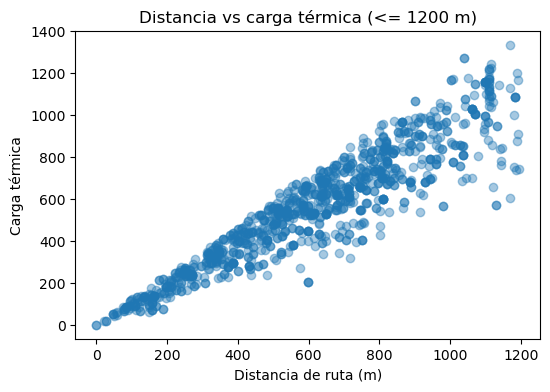

In [24]:
plt.figure(figsize=(6, 4))
plt.scatter(results_salud_walk["route_length_m"], results_salud_walk["heat_load"], alpha=0.4)
plt.xlabel("Distancia de ruta (m)")
plt.ylabel("Carga térmica")
plt.title(f"Distancia vs carga térmica (<= {UMBRAL_CAMINATA_M} m)")
plt.show()

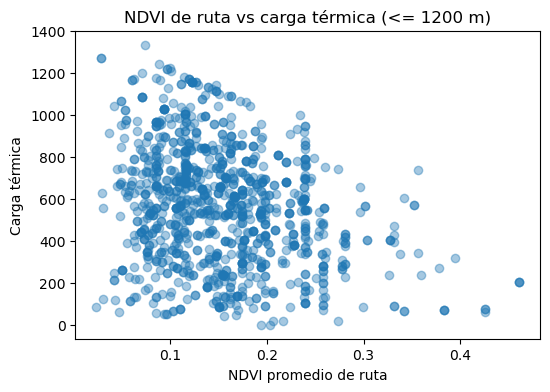

In [25]:
plt.figure(figsize=(6, 4))
plt.scatter(results_salud_walk["ndvi_route"], results_salud_walk["heat_load"], alpha=0.4)
plt.xlabel("NDVI promedio de ruta")
plt.ylabel("Carga térmica")
plt.title(f"NDVI de ruta vs carga térmica (<= {UMBRAL_CAMINATA_M} m)")
plt.show()

In [26]:
print(
    manz_plot[["heat_mean", "ndvi_mean"]]
    .dropna()
    .corr()
)

print(
    results_salud_walk[["heat_load", "ndvi_route", "route_length_m"]]
    .dropna()
    .corr()
)

           heat_mean  ndvi_mean
heat_mean   1.000000  -0.235116
ndvi_mean  -0.235116   1.000000
                heat_load  ndvi_route  route_length_m
heat_load        1.000000   -0.287761        0.928362
ndvi_route      -0.287761    1.000000        0.011303
route_length_m   0.928362    0.011303        1.000000


In [27]:
# --------------------------------------------------
# Sensibilidad simple al umbral de caminata
# --------------------------------------------------

for umbral in [800, 1200, 1500]:
    tmp = results_salud[results_salud["route_length_m"] <= umbral].copy()

    print(f"\n--- Umbral = {umbral} m ---")
    print("n viajes:", tmp.shape[0])

    if tmp.shape[0] > 0:
        print(tmp.groupby("vuln_group")["heat_load"].mean())
        print(tmp["risk_level"].value_counts(normalize=True))


--- Umbral = 800 m ---
n viajes: 839
vuln_group
alta     515.807164
baja     304.211283
media    439.798263
Name: heat_load, dtype: float64
risk_level
bajo     0.899881
medio    0.100119
Name: proportion, dtype: float64

--- Umbral = 1200 m ---
n viajes: 1164
vuln_group
alta     645.250990
baja     397.441701
media    554.000509
Name: heat_load, dtype: float64
risk_level
bajo     0.693299
medio    0.298969
alto     0.007732
Name: proportion, dtype: float64

--- Umbral = 1500 m ---
n viajes: 1244
vuln_group
alta     685.552742
baja     451.977150
media    569.393288
Name: heat_load, dtype: float64
risk_level
bajo     0.651125
medio    0.319132
alto     0.029743
Name: proportion, dtype: float64


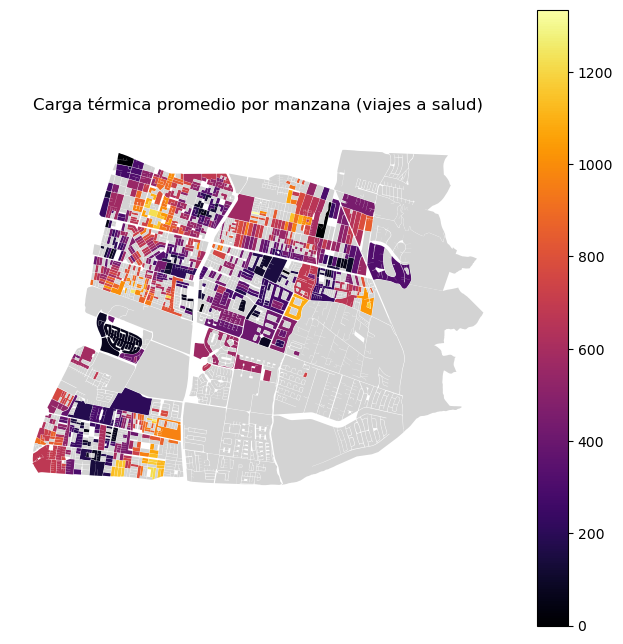

In [28]:
# --------------------------------------------------
# Mapa 1: carga térmica promedio
# --------------------------------------------------

ax = manz_plot.plot(
    column="heat_mean",
    cmap="inferno",
    legend=True,
    figsize=(8, 8),
    missing_kwds={"color": "lightgrey", "label": "Sin agentes salud"}
)
ax.set_title("Carga térmica promedio por manzana (viajes a salud)")
ax.set_axis_off()
plt.show()

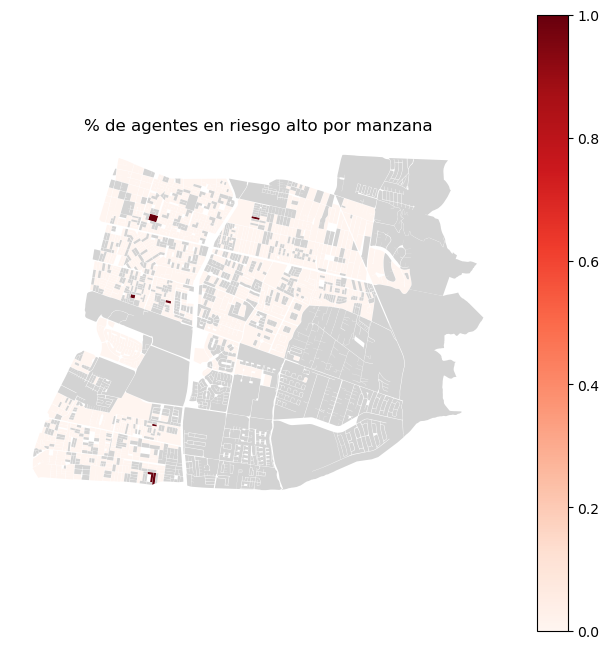

In [29]:
# --------------------------------------------------
# Mapa 2: porcentaje de riesgo alto
# --------------------------------------------------

ax = manz_plot.plot(
    column="pct_risk_high",
    cmap="Reds",
    legend=True,
    figsize=(8, 8),
    missing_kwds={"color": "lightgrey", "label": "Sin agentes salud"}
)
ax.set_title("% de agentes en riesgo alto por manzana")
ax.set_axis_off()
plt.show()

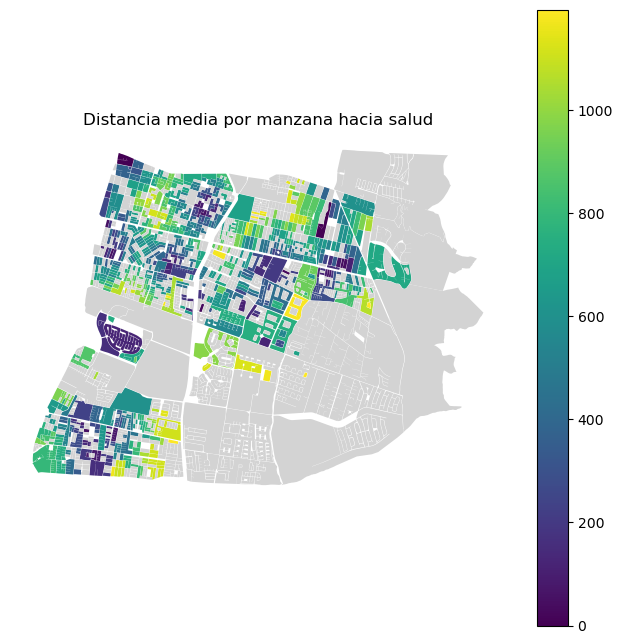

In [30]:
# --------------------------------------------------
# Mapa 3: distancia media a salud
# --------------------------------------------------

ax = manz_plot.plot(
    column="dist_mean_m",
    cmap="viridis",
    legend=True,
    figsize=(8, 8),
    missing_kwds={"color": "lightgrey", "label": "Sin agentes salud"}
)
ax.set_title("Distancia media por manzana hacia salud")
ax.set_axis_off()
plt.show()

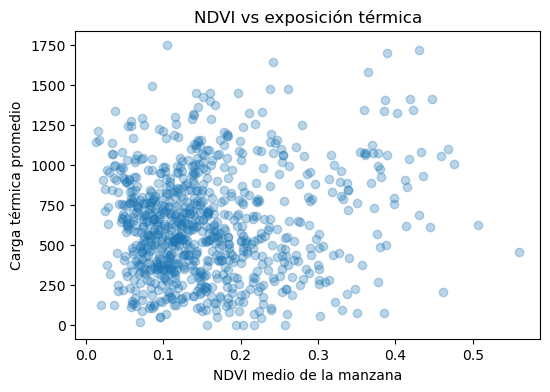

In [51]:
plt.figure(figsize=(6, 4))
plt.scatter(manz_plot["ndvi_mean"], manz_plot["heat_mean"], alpha=0.3)
plt.xlabel("NDVI medio de la manzana")
plt.ylabel("Carga térmica promedio")
plt.title("NDVI vs exposición térmica")
plt.show()

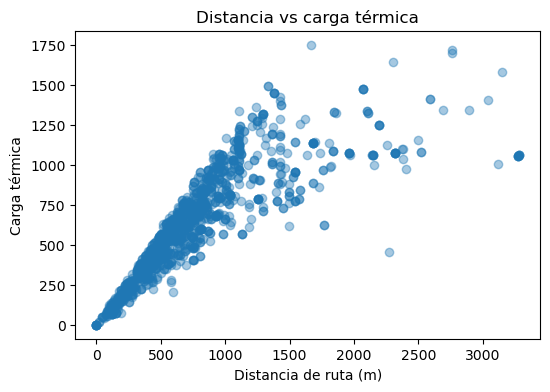

In [52]:
plt.figure(figsize=(6, 4))
plt.scatter(results_salud["route_length_m"], results_salud["heat_load"], alpha=0.4)
plt.xlabel("Distancia de ruta (m)")
plt.ylabel("Carga térmica")
plt.title("Distancia vs carga térmica")
plt.show()

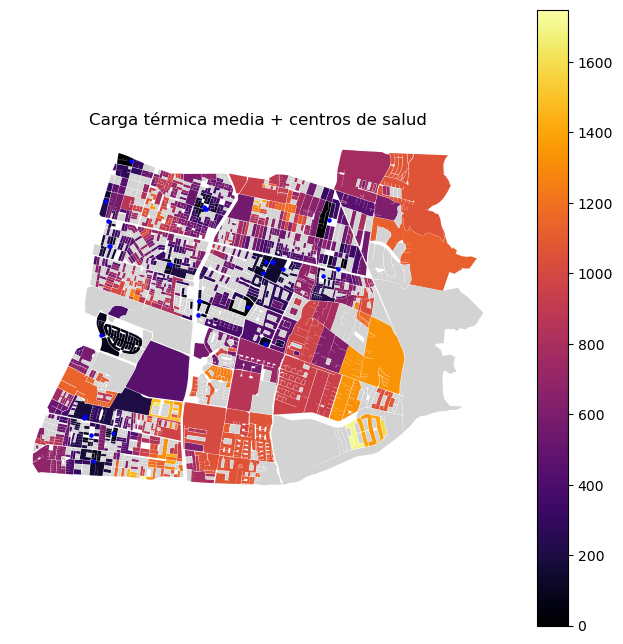

In [53]:
ax = manz_plot.plot(
    column="heat_mean",
    cmap="inferno",
    legend=True,
    figsize=(8, 8),
    missing_kwds={"color": "lightgrey"}
)
centros.plot(ax=ax, color="blue", markersize=5)
ax.set_title("Carga térmica media + centros de salud")
ax.set_axis_off()
plt.show()

In [55]:
print(results_salud["ndvi_route"].describe())
print(results_salud[["route_length_m", "ndvi_route", "heat_load"]].describe())

count    1321.000000
mean        0.171422
std         0.085028
min         0.022222
25%         0.110367
50%         0.155986
75%         0.218644
max         0.559720
Name: ndvi_route, dtype: float64
       route_length_m   ndvi_route    heat_load
count     1321.000000  1321.000000  1321.000000
mean       779.357620     0.171422   638.460597
std        527.656826     0.085028   325.097562
min          0.000000     0.022222     0.000000
25%        434.005000     0.110367   399.583188
50%        679.917000     0.155986   617.781033
75%        960.215000     0.218644   843.493426
max       3282.466000     0.559720  1748.817613


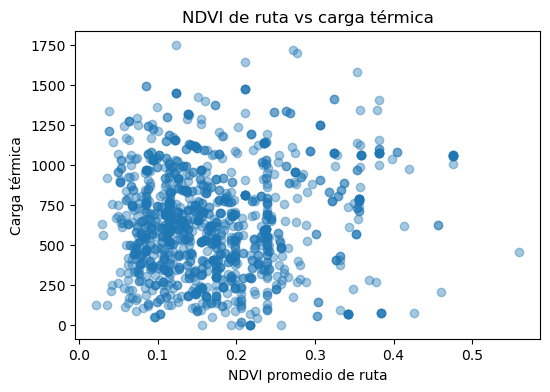

In [57]:
plt.figure(figsize=(6,4))
plt.scatter(results_salud["ndvi_route"], results_salud["heat_load"], alpha=0.4)
plt.xlabel("NDVI promedio de ruta")
plt.ylabel("Carga térmica")
plt.title("NDVI de ruta vs carga térmica")
plt.show()

In [59]:
results_salud["vf"] = results_salud["vuln_group"].map({
    "baja": 1.0,
    "media": 1.10,
    "alta": 1.25
})

results_salud["heat_per_m"] = results_salud["heat_load"] / (
    results_salud["route_length_m"] * results_salud["vf"]
)

results_salud["heat_per_m"].describe()

count    1312.000000
mean        0.769287
std         0.124869
min         0.200000
25%         0.699441
50%         0.792685
75%         0.859160
max         0.987481
Name: heat_per_m, dtype: float64

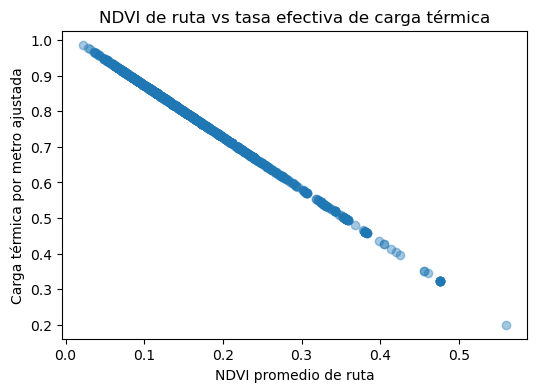

In [60]:
plt.figure(figsize=(6,4))
plt.scatter(results_salud["ndvi_route"], results_salud["heat_per_m"], alpha=0.4)
plt.xlabel("NDVI promedio de ruta")
plt.ylabel("Carga térmica por metro ajustada")
plt.title("NDVI de ruta vs tasa efectiva de carga térmica")
plt.show()